# Imports 

In [14]:
import numpy as np 
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # reproducible randomness

In [15]:
im = plt.imread('/Users/zohairshafi/Downloads/test.png')

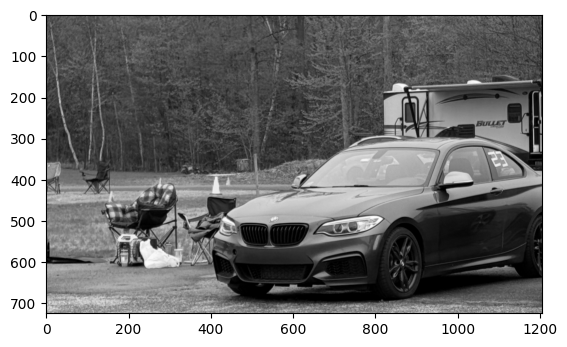

In [16]:
plt.imshow(im[:, :, 0], cmap='gray')

In [19]:
# Define filters
vertical_edge_filter = np.array([[1, 0, -1],
                                 [1, 0, -1],
                                 [1, 0, -1]])

horizontal_edge_filter = np.array([[1, 1, 1],
                                   [0, 0, 0],
                                   [-1, -1, -1]])

blur_filter = np.ones((3, 3)) / 9

sharper_filter = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])

channel = im[:, :, 0]

# Padding 
pad_h, pad_w = vertical_edge_filter.shape[0] // 2, vertical_edge_filter.shape[1] // 2
padded = np.pad(channel, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')

# Convolution using sliding window and tensordot
windows = np.lib.stride_tricks.sliding_window_view(padded, vertical_edge_filter.shape)
vertical_filtered_image = np.tensordot(windows, vertical_edge_filter, axes=((2, 3), (0, 1)))
horizontal_filtered_image = np.tensordot(windows, horizontal_edge_filter, axes=((2, 3), (0, 1)))
blurred_image = np.tensordot(windows, blur_filter, axes=((2, 3), (0, 1)))
sharper_image = np.tensordot(windows, sharper_filter, axes=((2, 3), (0, 1)))


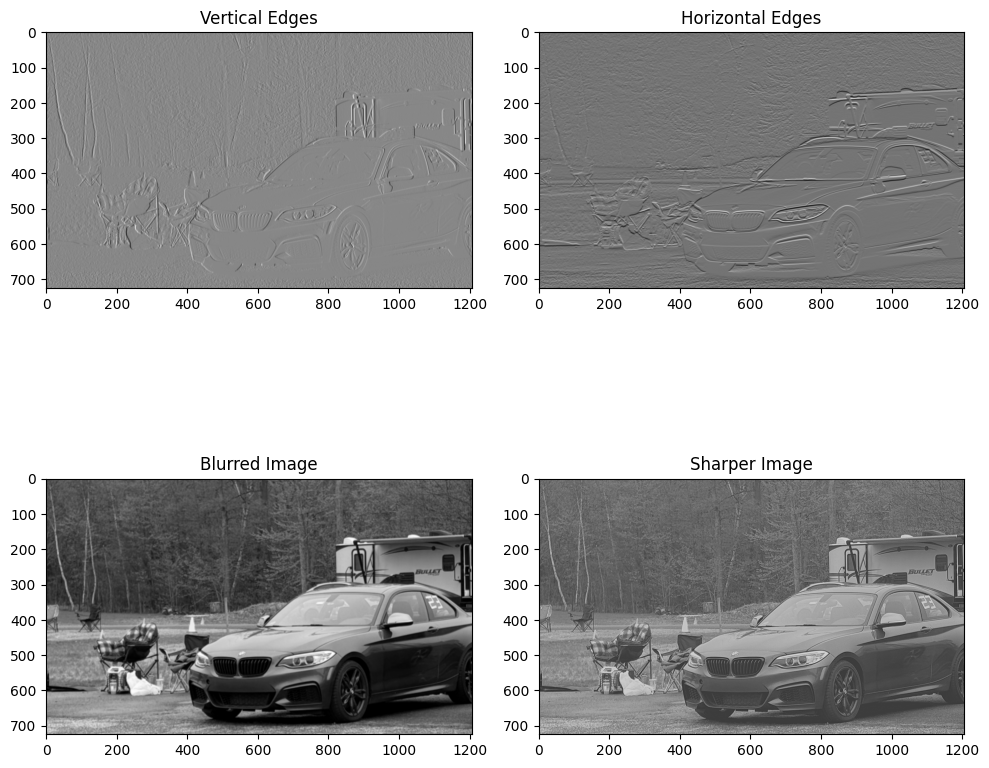

In [20]:
plt.subplots(2, 2, figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(vertical_filtered_image, cmap='gray')
plt.title('Vertical Edges')
plt.subplot(2, 2, 2)
plt.imshow(horizontal_filtered_image, cmap='gray')
plt.title('Horizontal Edges')
plt.subplot(2, 2, 3)
plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image')
plt.subplot(2, 2, 4)
plt.imshow(sharper_image, cmap='gray')
plt.title('Sharper Image')
plt.tight_layout()
plt.show()